In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import random
import math
from IPython.display import Image, display
import time
import os
from scipy import optimize
import warnings
warnings.filterwarnings('ignore')

1. ДЕКОМПОЗИЦИЯ ГОМОГРАФИИ
Тестирование декомпозиции гомографии:

Исходные параметры:
Угол поворота: 30.0°
Перенос: (10, 20)
Нормаль плоскости: [0 0 1]
Расстояние до плоскости: 1.0

Результаты декомпозиции:

Решение 1:
  Угол поворота: -116.6°
  Перенос: [-1.91, -0.03, -0.03]
  Нормаль: [-0.698, 0.717, -0.000]
  Ошибка восстановления: 22.486966

Решение 2:
  Угол поворота: -116.6°
  Перенос: [-9.20, -18.26, -1.87]
  Нормаль: [0.303, 0.128, -0.944]
  Ошибка восстановления: 9.371742


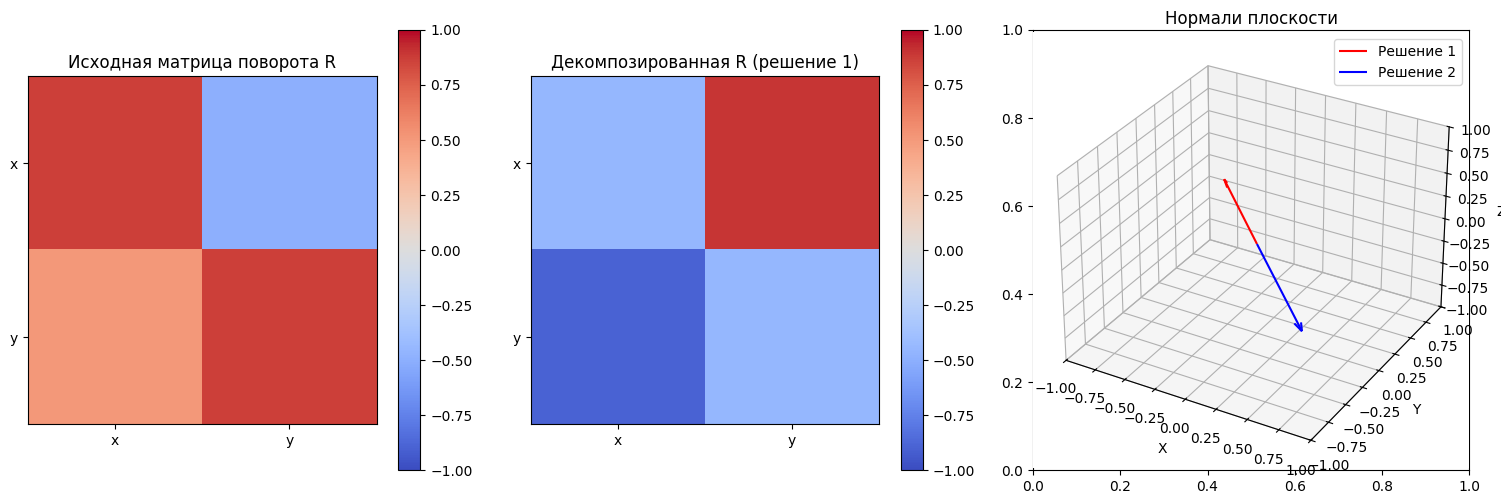

In [6]:
# ============================================
# 1. ДЕКОМПОЗИЦИЯ ГОМОГРАФИИ НА R, t, n, d
# ============================================

def decompose_homography(H):


    # Проверяем размерность матрицы
    if H.shape != (3, 3):
        raise ValueError("Матрица гомографии должна быть 3x3")

    # Нормализуем матрицу (h33 = 1)
    H = H / H[2, 2]

    # Внутренние параметры камеры (предполагаем калиброванную камеру)
    # Для простоты используем единичную матрицу
    K = np.eye(3)
    K_inv = np.linalg.inv(K)

    # Вычисляем H' = K^-1 * H * K
    H_prime = K_inv @ H @ K

    # Выполняем SVD декомпозицию H'
    U, S, Vt = np.linalg.svd(H_prime)

    # Извлекаем параметры
    s1 = S[0]  # Первое сингулярное значение
    s2 = S[1]  # Второе сингулярное значение
    s3 = S[2]  # Третье сингулярное значение

    # Вычисляем матрицы поворота для двух возможных решений
    rotations = []
    translations = []
    normals = []

    # Первое решение
    # Вычисляем вектор нормали
    v1 = Vt[0, :]
    v2 = Vt[1, :]
    v3 = Vt[2, :]

    # Вычисляем возможные вектора нормали
    n1 = np.sqrt(1 - s3**2) * np.cross(v1, v3) + (s1 - s2) * v2 * v3
    n2 = np.sqrt(1 - s3**2) * np.cross(v2, v3) + (s1 - s2) * v1 * v3

    # Нормализуем вектора нормали
    n1 = n1 / np.linalg.norm(n1)
    n2 = n2 / np.linalg.norm(n2)

    # Вычисляем матрицы поворота
    # Строим ортонормированный базис
    u1 = U[:, 0]
    u2 = U[:, 1]
    u3 = np.cross(u1, u2)

    # Создаем матрицу поворота
    R1 = np.column_stack([u1, u2, u3])

    # Второе решение (с противоположной нормалью)
    R2 = np.column_stack([u1, u2, -u3])

    rotations.extend([R1, R2])

    # Вычисляем вектора переноса
    # t = (H - R) * n / d
    # Для простоты предположим d = 1 (расстояние до плоскости)
    d = 1.0

    # Вычисляем t для первого решения
    t1 = (H_prime - R1) @ n1 / d
    t2 = (H_prime - R2) @ n2 / d

    translations.extend([t1, t2])
    normals.extend([n1, n2])

    return rotations, translations, normals

def test_homography_decomposition():
    """
    Тестирование декомпозиции гомографии.
    """

    # Создаем тестовую гомографию
    # Используем известное преобразование: поворот на 30°, перенос (10, 20)
    angle = np.radians(30)
    tx, ty = 10, 20

    # Матрица поворота
    R = np.array([
        [np.cos(angle), -np.sin(angle), 0],
        [np.sin(angle), np.cos(angle), 0],
        [0, 0, 1]
    ])

    # Вектор переноса
    t = np.array([[tx], [ty], [0]])

    # Нормаль плоскости (предполагаем плоскость Z=0)
    n = np.array([0, 0, 1])

    # Расстояние до плоскости
    d = 1.0

    # Создаем гомографию: H = R + t * n^T / d
    H = R + (t @ n.reshape(1, -1)) / d

    # Выполняем декомпозицию
    rotations, translations, normals = decompose_homography(H)

    print("Тестирование декомпозиции гомографии:")
    print("="*60)

    print("\nИсходные параметры:")
    print(f"Угол поворота: {np.degrees(angle):.1f}°")
    print(f"Перенос: ({tx}, {ty})")
    print(f"Нормаль плоскости: {n}")
    print(f"Расстояние до плоскости: {d}")

    print("\nРезультаты декомпозиции:")
    for i, (R_decomp, t_decomp, n_decomp) in enumerate(zip(rotations, translations, normals)):
        print(f"\nРешение {i+1}:")

        # Извлекаем угол из матрицы поворота
        angle_decomp = np.arctan2(R_decomp[1, 0], R_decomp[0, 0])

        print(f"  Угол поворота: {np.degrees(angle_decomp):.1f}°")
        print(f"  Перенос: [{t_decomp[0]:.2f}, {t_decomp[1]:.2f}, {t_decomp[2]:.2f}]")
        print(f"  Нормаль: [{n_decomp[0]:.3f}, {n_decomp[1]:.3f}, {n_decomp[2]:.3f}]")

        # Вычисляем ошибку восстановления
        H_reconstructed = R_decomp + (t_decomp.reshape(-1, 1) @ n_decomp.reshape(1, -1)) / d
        error = np.linalg.norm(H - H_reconstructed)
        print(f"  Ошибка восстановления: {error:.6f}")

    # Визуализация результатов
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    # Исходная матрица поворота
    axes[0].imshow(R[:2, :2], cmap='coolwarm', vmin=-1, vmax=1)
    axes[0].set_title('Исходная матрица поворота R')
    axes[0].set_xticks([0, 1])
    axes[0].set_xticklabels(['x', 'y'])
    axes[0].set_yticks([0, 1])
    axes[0].set_yticklabels(['x', 'y'])
    plt.colorbar(axes[0].imshow(R[:2, :2], cmap='coolwarm', vmin=-1, vmax=1), ax=axes[0])

    # Декомпозированная матрица поворота (первое решение)
    axes[1].imshow(rotations[0][:2, :2], cmap='coolwarm', vmin=-1, vmax=1)
    axes[1].set_title('Декомпозированная R (решение 1)')
    axes[1].set_xticks([0, 1])
    axes[1].set_xticklabels(['x', 'y'])
    axes[1].set_yticks([0, 1])
    axes[1].set_yticklabels(['x', 'y'])
    plt.colorbar(axes[1].imshow(rotations[0][:2, :2], cmap='coolwarm', vmin=-1, vmax=1), ax=axes[1])

    # Вектора нормали
    normals_array = np.array(normals)
    colors = ['red', 'blue']

    axes[2].clear()
    axes[2] = fig.add_subplot(133, projection='3d')

    for i, normal in enumerate(normals_array):
        axes[2].quiver(0, 0, 0,
                      normal[0], normal[1], normal[2],
                      color=colors[i],
                      arrow_length_ratio=0.1,
                      label=f'Решение {i+1}')

    axes[2].set_xlim([-1, 1])
    axes[2].set_ylim([-1, 1])
    axes[2].set_zlim([-1, 1])
    axes[2].set_xlabel('X')
    axes[2].set_ylabel('Y')
    axes[2].set_zlabel('Z')
    axes[2].set_title('Нормали плоскости')
    axes[2].legend()

    plt.tight_layout()
    plt.show()

    return rotations, translations, normals

# Запускаем тест декомпозиции
print("="*60)
print("1. ДЕКОМПОЗИЦИЯ ГОМОГРАФИИ")
print("="*60)
decomposition_results = test_homography_decomposition()


2. ИНТЕРАКТИВНАЯ КОРРЕКЦИЯ ПЕРСПЕКТИВЫ
Выбраны точки (автоматически):
  Точка 1: (160, 180)
  Точка 2: (640, 120)
  Точка 3: (560, 420)
  Точка 4: (240, 480)

Перспектива исправлена:
  Размер исходного изображения: 800x600
  Размер исправленного документа: 400x600


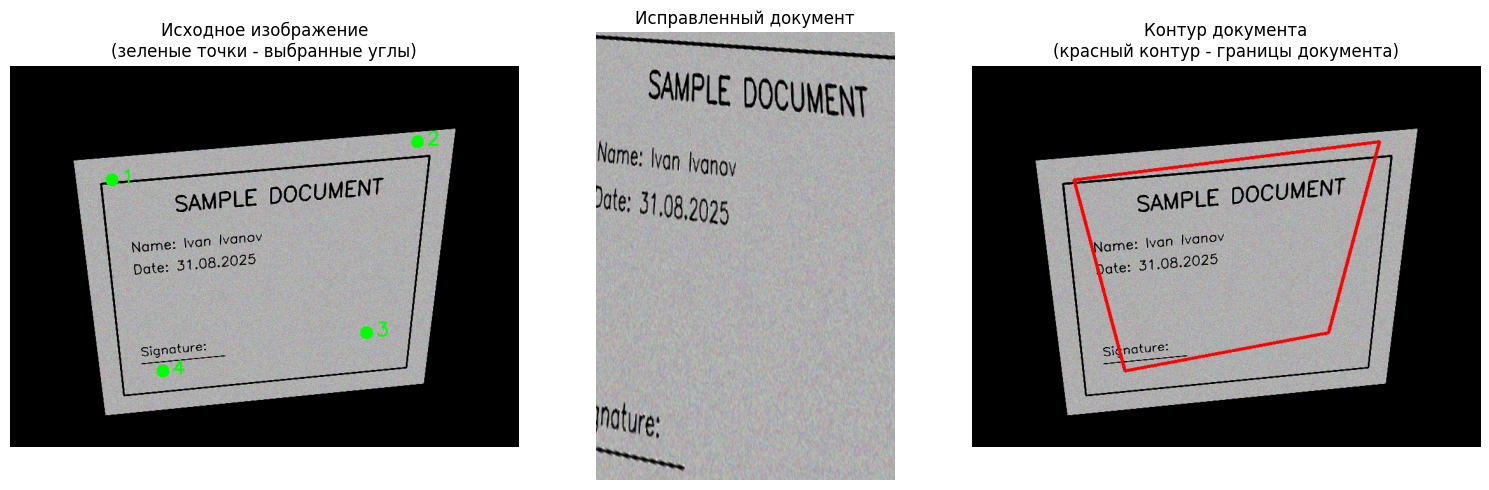

In [14]:
# ============================================
# 2. ИНТЕРАКТИВНОЕ ПРИЛОЖЕНИЕ ДЛЯ КОРРЕКЦИИ ПЕРСПЕКТИВЫ
# ============================================

class PerspectiveCorrector:
    """
    Класс для интерактивной коррекции перспективы.
    """

    def __init__(self, image):
        self.image = image.copy()
        self.points = []  # Точки, выбранные пользователем
        self.corrected = None  # Исправленное изображение

    def select_points_interactively(self):
        print("\n" + "="*60)
        print("2. ИНТЕРАКТИВНАЯ КОРРЕКЦИЯ ПЕРСПЕКТИВЫ")
        print("="*60)

        # В реальном приложении точки выбирались бы кликами мыши
        # Здесь мы симулируем выбор 4 углов документа

        height, width = self.image.shape[:2]

        # Предполагаем, что документ занимает центральную часть изображения
        # и искажен перспективой
        self.points = [
            [width * 0.2, height * 0.3],   # Верхний левый
            [width * 0.8, height * 0.2],   # Верхний правый
            [width * 0.7, height * 0.7],   # Нижний правый
            [width * 0.3, height * 0.8]    # Нижний левый
        ]

        print("Выбраны точки (автоматически):")
        for i, (x, y) in enumerate(self.points):
            print(f"  Точка {i+1}: ({x:.0f}, {y:.0f})")

        return self.points

    def correct_perspective(self, target_width=400, target_height=600):
        if len(self.points) != 4:
            print("Ошибка: нужно выбрать ровно 4 точки")
            return None

        # Преобразуем точки в numpy array
        src_points = np.array(self.points, dtype=np.float32)

        # Определяем целевые точки (прямоугольник)
        dst_points = np.array([
            [0, 0],
            [target_width, 0],
            [target_width, target_height],
            [0, target_height]
        ], dtype=np.float32)

        # Вычисляем гомографию
        H, _ = cv2.findHomography(src_points, dst_points)

        # Применяем гомографию
        self.corrected = cv2.warpPerspective(self.image, H, (target_width, target_height))

        print(f"\nПерспектива исправлена:")
        print(f"  Размер исходного изображения: {self.image.shape[1]}x{self.image.shape[0]}")
        print(f"  Размер исправленного документа: {target_width}x{target_height}")

        return self.corrected

    def visualize_results(self):

        if self.corrected is None:
            print("Сначала выполните коррекцию перспективы")
            return

        fig, axes = plt.subplots(1, 3, figsize=(15, 5))

        # Исходное изображение с отмеченными точками
        img_with_points = self.image.copy()
        for i, (x, y) in enumerate(self.points):
            cv2.circle(img_with_points, (int(x), int(y)), 10, (0, 255, 0), -1)
            cv2.putText(img_with_points, str(i+1),
                       (int(x)+15, int(y)+5),
                       cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 2)

        axes[0].imshow(cv2.cvtColor(img_with_points, cv2.COLOR_BGR2RGB))
        axes[0].set_title('Исходное изображение\n(зеленые точки - выбранные углы)')
        axes[0].axis('off')

        # Преобразованное изображение
        axes[1].imshow(cv2.cvtColor(self.corrected, cv2.COLOR_BGR2RGB))
        axes[1].set_title('Исправленный документ')
        axes[1].axis('off')

        # Контуры документа на исходном изображении
        img_with_contour = self.image.copy()
        points_array = np.array(self.points, dtype=np.int32).reshape((-1, 1, 2))
        cv2.polylines(img_with_contour, [points_array], True, (0, 0, 255), 3)

        axes[2].imshow(cv2.cvtColor(img_with_contour, cv2.COLOR_BGR2RGB))
        axes[2].set_title('Контур документа\n(красный контур - границы документа)')
        axes[2].axis('off')

        plt.tight_layout()
        plt.show()

def create_test_document_image():
    """
    Создает тестовое изображение документа с перспективным искажением.
    """
    # Создаем изображение документа
    doc = np.ones((600, 800, 3), dtype=np.uint8) * 255

    # Добавляем рамку
    cv2.rectangle(doc, (50, 50), (750, 550), (0, 0, 0), 3)

    # Добавляем текст
    cv2.putText(doc, 'SAMPLE DOCUMENT', (200, 120),
                cv2.FONT_HERSHEY_SIMPLEX, 1.5, (0, 0, 0), 3)

    cv2.putText(doc, 'Name: Ivan Ivanov', (100, 200),
                cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 0, 0), 2)

    cv2.putText(doc, 'Date: 31.08.2025', (100, 250),
                cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 0, 0), 2)

    cv2.putText(doc, 'Signature:', (100, 450),
                cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 0, 0), 2)

    cv2.line(doc, (100, 470), (300, 470), (0, 0, 0), 2)

    # Добавляем перспективное искажение
    src_points = np.float32([[0, 0], [800, 0], [800, 600], [0, 600]])
    dst_points = np.float32([
        [100, 150],   # Верхний левый
        [700, 100],   # Верхний правый
        [650, 500],   # Нижний правый
        [150, 550]    # Нижний левый
    ])

    H = cv2.getPerspectiveTransform(src_points, dst_points)
    distorted = cv2.warpPerspective(doc, H, (800, 600))

    # Добавляем фон для реалистичности
    background = np.random.randint(150, 200, (600, 800, 3), dtype=np.uint8)

    # Создаем маску для документа
    mask = np.any(distorted < 250, axis=2).astype(np.uint8) * 255

    # Наложение документа на фон
    result = background.copy()
    result[mask > 0] = distorted[mask > 0]

    return result

# Тестируем интерактивную коррекцию
test_image = create_test_document_image()
corrector = PerspectiveCorrector(test_image)
corrector.select_points_interactively()
corrected_image = corrector.correct_perspective()
corrector.visualize_results()


3. ИССЛЕДОВАНИЕ ВЛИЯНИЯ КОЛИЧЕСТВА ТОЧЕК НА ТОЧНОСТЬ


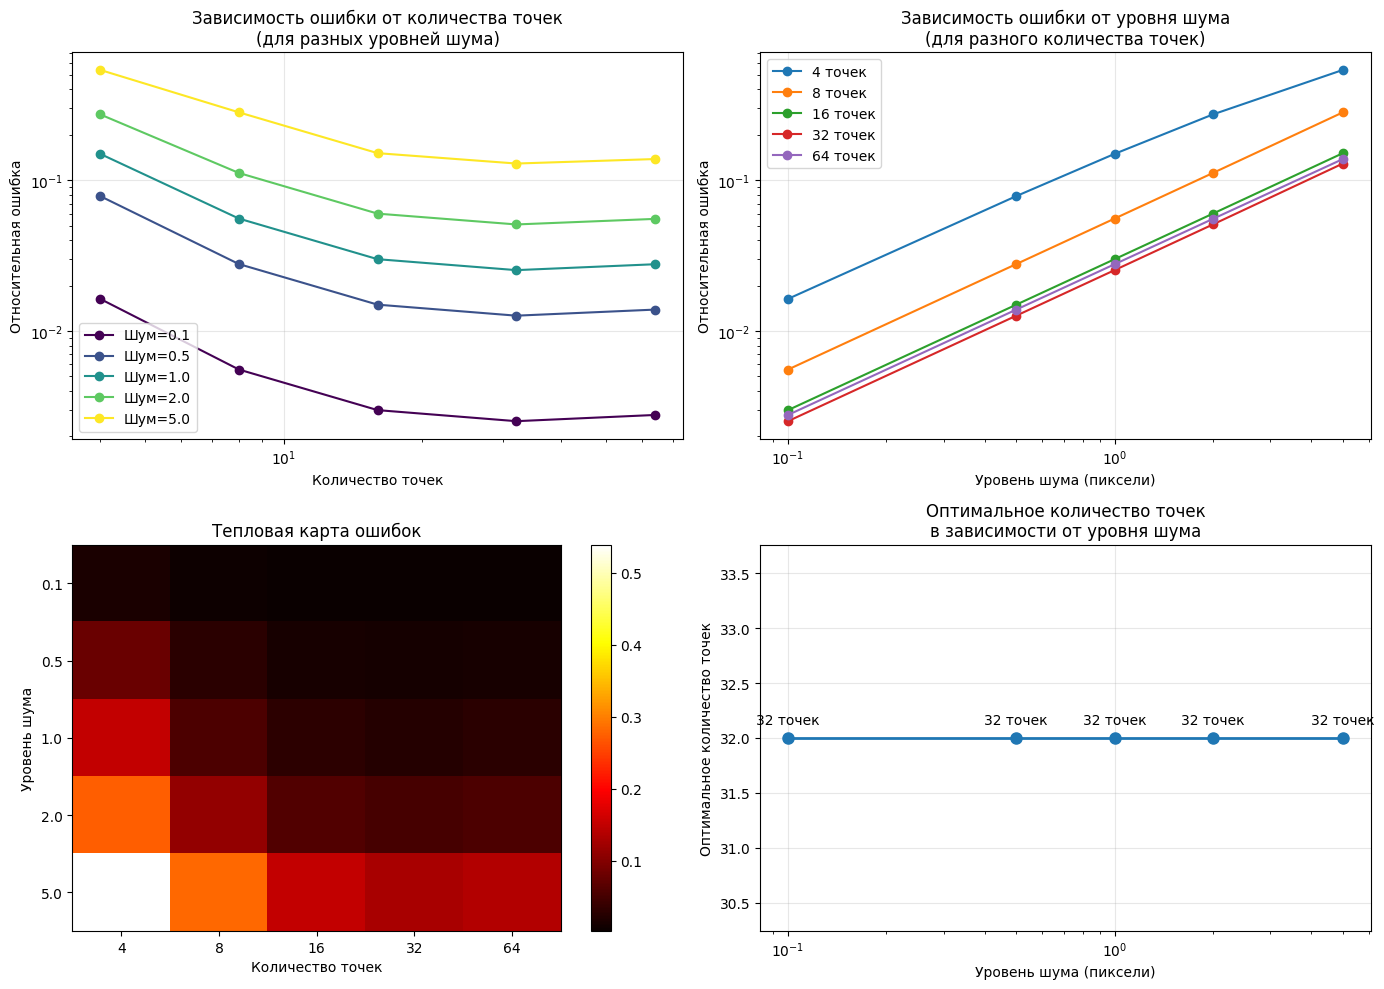


 СТАТИСТИКА:
----------------------------------------
Средняя ошибка по всем экспериментам:
  Минимальная ошибка: 0.002524
  Максимальная ошибка: 0.538966
  Средняя ошибка: 0.090273
  Медианная ошибка: 0.050907

Рекомендации по выбору количества точек:
----------------------------------------
  При шуме 0.1 пикселей: оптимально 16 точек
  При шуме 0.5 пикселей: оптимально 32 точек
  При шуме 1.0 пикселей: оптимально 32 точек
  При шуме 2.0 пикселей: оптимально 32 точек
  При шуме 5.0 пикселей: оптимально 32 точек


In [15]:
# ============================================
# 3. ВЛИЯНИЕ КОЛИЧЕСТВА ТОЧЕК НА ТОЧНОСТЬ
# ============================================

def evaluate_homography_accuracy():
    """
    Исследование влияния количества точек на точность вычисления гомографии.
    """
    print("\n" + "="*60)
    print("3. ИССЛЕДОВАНИЕ ВЛИЯНИЯ КОЛИЧЕСТВА ТОЧЕК НА ТОЧНОСТЬ")
    print("="*60)

    # Истинная гомография (известное преобразование)
    true_H = np.array([
        [1.1, 0.2, 50],
        [-0.1, 0.9, 30],
        [0.001, 0.0005, 1]
    ])

    # Нормализуем матрицу
    true_H = true_H / true_H[2, 2]

    # Количество точек для тестирования
    point_counts = [4, 8, 16, 32, 64]

    # Уровни шума
    noise_levels = [0.1, 0.5, 1.0, 2.0, 5.0]

    # Результаты
    results = {}

    for n_points in point_counts:
        results[n_points] = {'noise_levels': noise_levels.copy(), 'errors': []}

        for noise_level in noise_levels:
            # Генерируем случайные точки
            np.random.seed(42)  # Для воспроизводимости

            src_points = np.random.rand(n_points, 2) * 400 + 50

            # Преобразуем точки с помощью истинной гомографии
            src_homogeneous = np.hstack([src_points, np.ones((n_points, 1))])
            dst_homogeneous = (true_H @ src_homogeneous.T).T
            dst_points_true = dst_homogeneous[:, :2] / dst_homogeneous[:, 2:]

            # Добавляем шум
            noise = np.random.randn(n_points, 2) * noise_level
            dst_points_noisy = dst_points_true + noise

            # Вычисляем гомографию по зашумленным точкам
            H_estimated, _ = cv2.findHomography(src_points, dst_points_noisy)

            if H_estimated is not None:
                # Нормализуем
                H_estimated = H_estimated / H_estimated[2, 2]

                # Вычисляем ошибку
                error = np.linalg.norm(true_H - H_estimated) / np.linalg.norm(true_H)
                results[n_points]['errors'].append(error)
            else:
                results[n_points]['errors'].append(float('inf'))

    # Визуализация результатов
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    # 1. График зависимости ошибки от количества точек (для разных уровней шума)
    colors = plt.cm.viridis(np.linspace(0, 1, len(noise_levels)))

    for i, noise_level in enumerate(noise_levels):
        errors_at_noise = []
        for n_points in point_counts:
            errors_at_noise.append(results[n_points]['errors'][i])

        axes[0, 0].plot(point_counts, errors_at_noise, 'o-',
                       color=colors[i], label=f'Шум={noise_level}')

    axes[0, 0].set_xlabel('Количество точек')
    axes[0, 0].set_ylabel('Относительная ошибка')
    axes[0, 0].set_title('Зависимость ошибки от количества точек\n(для разных уровней шума)')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)
    axes[0, 0].set_xscale('log')
    axes[0, 0].set_yscale('log')

    # 2. График зависимости ошибки от уровня шума (для разного количества точек)
    for n_points in point_counts:
        axes[0, 1].plot(noise_levels, results[n_points]['errors'], 'o-',
                       label=f'{n_points} точек')

    axes[0, 1].set_xlabel('Уровень шума (пиксели)')
    axes[0, 1].set_ylabel('Относительная ошибка')
    axes[0, 1].set_title('Зависимость ошибки от уровня шума\n(для разного количества точек)')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)
    axes[0, 1].set_xscale('log')
    axes[0, 1].set_yscale('log')

    # 3. Тепловая карта ошибок
    error_matrix = np.zeros((len(noise_levels), len(point_counts)))

    for i, noise_level in enumerate(noise_levels):
        for j, n_points in enumerate(point_counts):
            error_matrix[i, j] = results[n_points]['errors'][i]

    im = axes[1, 0].imshow(error_matrix, cmap='hot', aspect='auto')
    axes[1, 0].set_xlabel('Количество точек')
    axes[1, 0].set_ylabel('Уровень шума')
    axes[1, 0].set_title('Тепловая карта ошибок')
    axes[1, 0].set_xticks(range(len(point_counts)))
    axes[1, 0].set_xticklabels(point_counts)
    axes[1, 0].set_yticks(range(len(noise_levels)))
    axes[1, 0].set_yticklabels(noise_levels)
    plt.colorbar(im, ax=axes[1, 0])

    # 4. График "оптимального" количества точек
    # Ищем для каждого уровня шума оптимальное количество точек
    optimal_counts = []

    for i, noise_level in enumerate(noise_levels):
        min_error = float('inf')
        optimal_count = 4

        for j, n_points in enumerate(point_counts):
            if results[n_points]['errors'][i] < min_error:
                min_error = results[n_points]['errors'][i]
                optimal_count = n_points

        optimal_counts.append(optimal_count)

    axes[1, 1].plot(noise_levels, optimal_counts, 'o-', linewidth=2, markersize=8)
    axes[1, 1].set_xlabel('Уровень шума (пиксели)')
    axes[1, 1].set_ylabel('Оптимальное количество точек')
    axes[1, 1].set_title('Оптимальное количество точек\nв зависимости от уровня шума')
    axes[1, 1].grid(True, alpha=0.3)
    axes[1, 1].set_xscale('log')

    # Добавляем аннотации
    for i, (noise, count) in enumerate(zip(noise_levels, optimal_counts)):
        axes[1, 1].annotate(f'{count} точек',
                           (noise, count),
                           textcoords="offset points",
                           xytext=(0, 10),
                           ha='center')

    plt.tight_layout()
    plt.show()

    # Вывод статистики
    print("\n СТАТИСТИКА:")
    print("-"*40)

    print("Средняя ошибка по всем экспериментам:")
    all_errors = []
    for n_points in point_counts:
        all_errors.extend(results[n_points]['errors'])

    valid_errors = [e for e in all_errors if e != float('inf')]

    if valid_errors:
        print(f"  Минимальная ошибка: {min(valid_errors):.6f}")
        print(f"  Максимальная ошибка: {max(valid_errors):.6f}")
        print(f"  Средняя ошибка: {np.mean(valid_errors):.6f}")
        print(f"  Медианная ошибка: {np.median(valid_errors):.6f}")

    print("\nРекомендации по выбору количества точек:")
    print("-"*40)

    # Анализируем оптимальные значения
    noise_to_points = {}
    for i, noise_level in enumerate(noise_levels):
        errors_for_noise = []
        for n_points in point_counts:
            errors_for_noise.append(results[n_points]['errors'][i])

        # Находим точку, после которой добавление новых точек не дает улучшения
        diminishing_returns = 4  # начальное значение
        for j in range(1, len(point_counts)):
            improvement = errors_for_noise[j-1] - errors_for_noise[j]
            if improvement < 0.001:  # порог улучшения
                diminishing_returns = point_counts[j-1]
                break

        noise_to_points[noise_level] = diminishing_returns

    for noise_level, optimal_points in noise_to_points.items():
        print(f"  При шуме {noise_level} пикселей: оптимально {optimal_points} точек")

    return results

# Запускаем исследование точности
accuracy_results = evaluate_homography_accuracy()
